In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
plt.style.use("default")

In [15]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01")

prices = data["Close"]
prices.head()

[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2020-01-02,72.400528
2020-01-03,71.696625
2020-01-06,72.267952
2020-01-07,71.928055
2020-01-08,73.085098


In [16]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01")

prices = data["Close"]
prices.head()


[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2020-01-02,72.400513
2020-01-03,71.696648
2020-01-06,72.267952
2020-01-07,71.928062
2020-01-08,73.085114


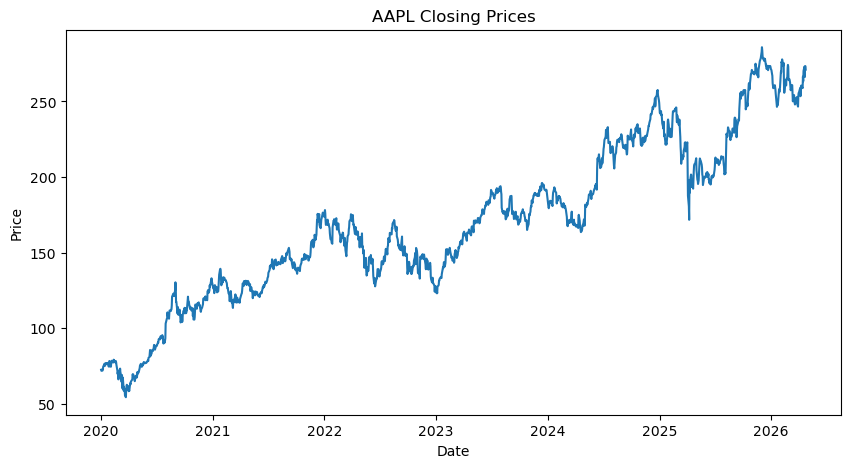

In [17]:
plt.figure(figsize=(10,5))
plt.plot(prices)
plt.title(f"{ticker} Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [18]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.head()

Ticker,AAPL
Date,
2020-01-03,-0.009769
2020-01-06,0.007937
2020-01-07,-0.004714
2020-01-08,0.015958
2020-01-09,0.021018


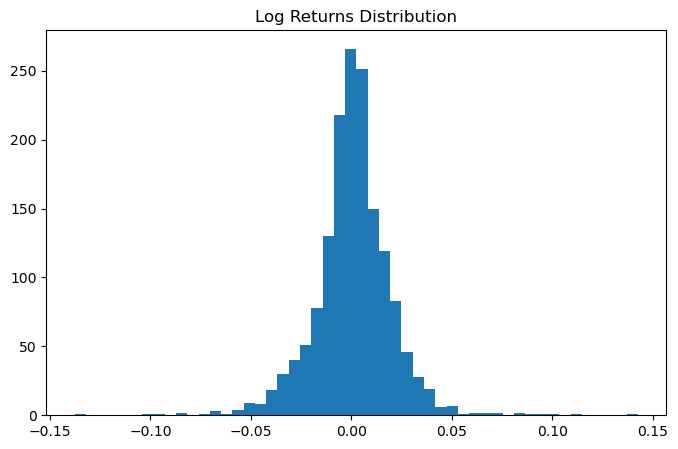

In [19]:
plt.figure(figsize=(8,5))
plt.hist(log_returns, bins=50)
plt.title("Log Returns Distribution")
plt.show()

In [20]:
mu = log_returns.mean() * 252
sigma = log_returns.std() * np.sqrt(252)

print("Estimated μ (drift):", mu)
print("Estimated σ (volatility):", sigma)

Estimated μ (drift): Ticker
AAPL    0.209888
dtype: float64
Estimated σ (volatility): Ticker
AAPL    0.314403
dtype: float64


In [21]:
# Ensure Series
prices = data["Close"]

# Log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

# Convert to scalar
mu = float(log_returns.mean() * 252)
sigma = float(log_returns.std() * np.sqrt(252))

# Setup
S0 = float(prices.iloc[-1])
T = 1
steps = 252
simulations = 1000

dt = 1 / steps
N = int(T * steps)

paths = np.zeros((N, simulations))
paths[0] = S0

# Simulation
for t in range(1, N):
    Z = np.random.standard_normal(simulations)
    paths[t] = paths[t-1] * np.exp(
        (mu - 0.5 * sigma**2)*dt + sigma * np.sqrt(dt)*Z
    )

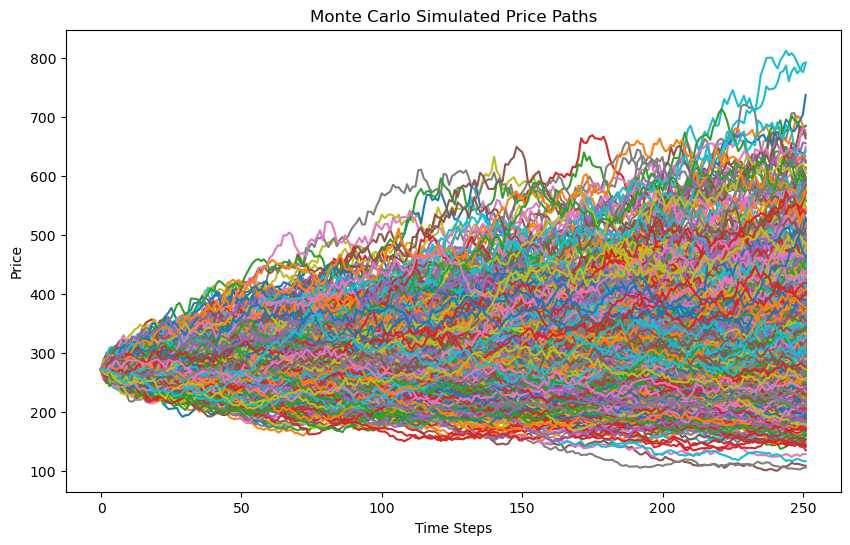

In [22]:
plt.figure(figsize=(10,6))
plt.plot(paths)
plt.title("Monte Carlo Simulated Price Paths")
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.show()

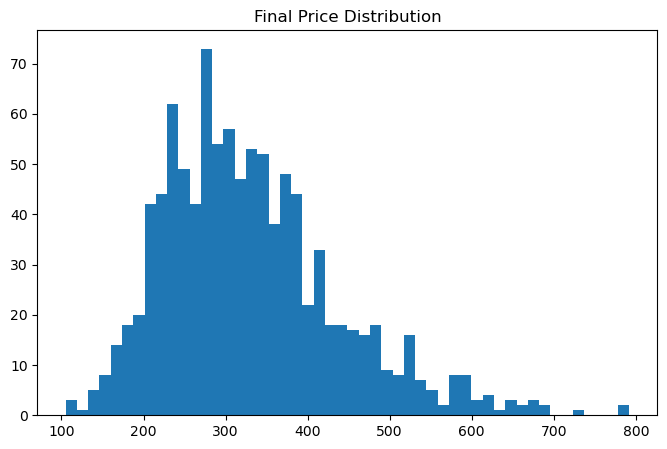

In [23]:
final_prices = paths[-1]

plt.figure(figsize=(8,5))
plt.hist(final_prices, bins=50)
plt.title("Final Price Distribution")
plt.show()

In [24]:
expected_price = np.mean(final_prices)
var_5 = np.percentile(final_prices, 5)

print("Expected Price:", expected_price)
print("Value at Risk (5%):", var_5)

Expected Price: 330.5806781769735
Value at Risk (5%): 189.01071683657005


### Interpretation

- The simulation generates multiple possible future price paths.
- The expected price represents the average outcome.
- Value at Risk (VaR) gives a measure of downside risk.
- The distribution shows uncertainty in future prices.

Limitations:
- Assumes constant volatility
- Ignores extreme market events